In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from glob import glob
from AdrenalInstance import AdrenalInstance

plt.rcParams.update({'font.size': 14}) 

/Users/jjiang10/conda_envs/adrenal/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from config import DATA_ROOT_DIR
processed_data_root_dir = os.path.join(DATA_ROOT_DIR, "processed_data")
Feature_data_dir = os.path.join(processed_data_root_dir, "grouped_instance_features")
attenuation_eval_dir = os.path.join(processed_data_root_dir, "attenuation_eval")
instances_multiple_delay_csv =  os.path.join(attenuation_eval_dir, "instances_multiple_delay_phases.csv")
clinical_data_file = os.path.join(processed_data_root_dir, "mrn_malignancy.csv")
HU_data_dir = os.path.join(processed_data_root_dir, "HU_array_adjusted")
Image_data_dir = os.path.join(processed_data_root_dir, "reconstructed_img_adjusted")

In [29]:
def calculate_lesion_HU(lesion_img, mask_img):
    lesion_img = np.load(lesion_img)
    mask_img = np.load(mask_img)
    masked_lesion = lesion_img[mask_img > 0]
    if masked_lesion.size == 0 or np.all(masked_lesion == 0):
        print("Warning: No lesion pixels found in the mask or all lesion pixels are zero.")
        return None 
    
    return np.mean(masked_lesion)

def read_HU_info(npy_fn_full_path):
    fn = os.path.split(npy_fn_full_path)[1]
    ele = fn.split("_")
    mrn = ele[0]
    study_date = ele[1]
    phase = ele[2]
    delay_time = int(ele[3])
    lesion_side = ele[4]
    HU = calculate_lesion_HU(npy_fn_full_path, npy_fn_full_path.replace(".npy", "_mask.npy"))
    return mrn, study_date, phase, delay_time, lesion_side, HU


In [30]:
NC_time_ranges = (-110,-60)
AR_time_ranges = (-60, -5)
PV_time_ranges = (-5, 5)
Delay_time_ranges = (5, 1100)

# Define phase boundaries (in seconds)
phases = {
    'NC': NC_time_ranges,
    'AR': AR_time_ranges,
    'PV': PV_time_ranges,
    'Delay': Delay_time_ranges
}
phase_colors = {
    'NC': '#c6e5ec',
    'AR': '#975557',
    'PV': '#fdc800',
    'Delay': '#6f3faa'
}

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, UnivariateSpline

def sample_pairs_to_arrays(sample_pairs):
    """
    Convert one sample: [(t, hu), ...] -> (t_array, hu_array), cleaned + sorted.
    - drops NaNs
    - sorts by t
    - averages duplicate t
    """
    if sample_pairs is None or len(sample_pairs) == 0:
        return np.array([]), np.array([])

    arr = np.asarray(sample_pairs, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("Each sample must be a list of (t, hu) pairs.")

    t = arr[:, 0]
    hu = arr[:, 1]
    m = np.isfinite(t) & np.isfinite(hu)
    t, hu = t[m], hu[m]

    if t.size < 2:
        return t, hu

    order = np.argsort(t)
    t, hu = t[order], hu[order]

    # average duplicates
    ut, inv = np.unique(t, return_inverse=True)
    if ut.size != t.size:
        hu_sum = np.zeros_like(ut, dtype=float)
        cnt = np.zeros_like(ut, dtype=float)
        for i, k in enumerate(inv):
            hu_sum[k] += hu[i]
            cnt[k] += 1
        hu = hu_sum / np.maximum(cnt, 1.0)
        t = ut

    return t, hu

def build_common_grid(samples, n_grid=120, method="linspace"):
    """Build a global grid from all timepoints across all samples."""
    all_t = []
    ranges = []
    for s in samples:
        t, hu = sample_pairs_to_arrays(s)
        if t.size >= 2:
            all_t.append(t)
            ranges.append((t.min(), t.max()))

    if not all_t:
        raise ValueError("No valid samples with >=2 points.")

    all_t = np.concatenate(all_t)
    tmin, tmax = float(np.nanmin(all_t)), float(np.nanmax(all_t))

    if method == "linspace":
        grid = np.linspace(tmin, tmax, n_grid)
    elif method == "quantile":
        qs = np.linspace(0, 1, n_grid)
        grid = np.quantile(all_t, qs)
        grid = np.unique(grid)
        if grid.size < 5:
            grid = np.linspace(tmin, tmax, n_grid)
    else:
        raise ValueError("method must be 'linspace' or 'quantile'.")

    return grid

def resample_samples(samples, grid_t, kind="linear", extrapolate=False):
    """
    Interpolate each sample onto grid_t.
    Returns X: (n_samples, len(grid_t)) with NaN outside observed range unless extrapolate=True.
    """
    grid_t = np.asarray(grid_t, dtype=float)
    X = np.full((len(samples), grid_t.size), np.nan, dtype=float)

    for i, s in enumerate(samples):
        t, hu = sample_pairs_to_arrays(s)
        if t.size < 2:
            continue

        fill = "extrapolate" if extrapolate else np.nan
        f = interp1d(t, hu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)
        X[i] = f(grid_t)

        if not extrapolate:
            # enforce NaN outside the original range (interp1d already does this with fill_value=np.nan)
            pass

    return X

def fit_spline(t, y, s=None, k=3):
    """Fit smoothing spline to (t, y) ignoring NaNs."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(t) & np.isfinite(y)
    t2, y2 = t[m], y[m]
    if t2.size < (k + 1):
        return None
    if s is None:
        s = max(1e-6, np.nanvar(y2) * len(y2))  # mild heuristic
    return UnivariateSpline(t2, y2, s=s, k=k)

def plot_class_attenuation_curves(samples, y, n_grid=120, grid_method="quantile",
                                  interp_kind="linear", spline_s=None,
                                  show_individual=False, max_individual=30):
    """
    Fits class-wise curves for positive vs negative and plots them + difference.
    samples: list of list of (t, hu)
    y: list/array of 0/1
    """
    y = np.asarray(y, dtype=int)
    if len(samples) != len(y):
        raise ValueError("len(samples) must equal len(y).")

    grid_t = build_common_grid(samples, n_grid=n_grid, method=grid_method)
    X = resample_samples(samples, grid_t, kind=interp_kind, extrapolate=False)

    pos = X[y == 1]
    neg = X[y == 0]
    if pos.shape[0] == 0 or neg.shape[0] == 0:
        raise ValueError("Need both positive and negative samples.")

    mu_pos = np.nanmean(pos, axis=0)
    mu_neg = np.nanmean(neg, axis=0)

    spl_pos = fit_spline(grid_t, mu_pos, s=spline_s)
    spl_neg = fit_spline(grid_t, mu_neg, s=spline_s)

    curve_pos = spl_pos(grid_t) if spl_pos is not None else mu_pos
    curve_neg = spl_neg(grid_t) if spl_neg is not None else mu_neg
    diff = curve_pos - curve_neg

    # quick uncertainty band: ±1 standard error on the grid
    def se(arr):
        n_eff = np.sum(np.isfinite(arr), axis=0)
        sd = np.nanstd(arr, axis=0, ddof=1)
        return sd / np.sqrt(np.maximum(n_eff, 1))

    se_pos = se(pos)
    se_neg = se(neg)

    # Plot curves
    plt.figure(figsize=(8, 5), dpi=300)
    if show_individual:
        rng = np.random.default_rng(0)
        for data, label in [(pos, "pos"), (neg, "neg")]:
            idx = np.arange(data.shape[0])
            if idx.size > max_individual:
                idx = rng.choice(idx, size=max_individual, replace=False)
            for j in idx:
                if label == "pos":
                    plt.plot(grid_t, data[j], c="red", alpha=0.15)
                else:
                    plt.plot(grid_t, data[j], c="blue", alpha=0.15)

    plt.plot(grid_t, curve_pos, c="red", label="Positive (smoothed mean)")
    plt.fill_between(grid_t, curve_pos - se_pos, curve_pos + se_pos, alpha=0.2, facecolor="red", label="Positive ±1 SE")

    plt.plot(grid_t, curve_neg, c="blue", label="Negative (smoothed mean)")
    plt.fill_between(grid_t, curve_neg - se_neg, curve_neg + se_neg, alpha=0.2, facecolor="blue", label="Negative ±1 SE")

    plt.xlabel("Time")
    plt.ylabel("HU")
    plt.title("Attenuation curves")
    plt.legend()
    plt.show()

    # Plot difference
    plt.figure()
    plt.plot(grid_t, diff, label="Difference (Positive - Negative)")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Time")
    plt.ylabel("ΔHU")
    plt.title("Class attenuation difference over time")
    plt.legend()
    plt.show()

    return {
        "grid_t": grid_t,
        "X_grid": X,
        "pos_curve": curve_pos,
        "neg_curve": curve_neg,
        "diff_curve": diff,
        "pos_spline": spl_pos,
        "neg_spline": spl_neg,
        "pos_mean_on_grid": mu_pos,
        "neg_mean_on_grid": mu_neg,
    }



Instance: MRN=707571, StudyDate=20070620, Delay Count=2, Available Phases=NC; PV; Delay; Delay, Malignancy=1
  Phase: PV, Delay Time: 0s, Lesion Side: LT.npy, HU: 133.40128205128204
  Phase: NC, Delay Time: -410s, Lesion Side: LT.npy, HU: 28.901282051282053
  Phase: Delay, Delay Time: 247s, Lesion Side: LT.npy, HU: 81.69871794871794
  Phase: Delay, Delay Time: 119s, Lesion Side: LT.npy, HU: 86.30128205128206
Instance: MRN=617155, StudyDate=20040524, Delay Count=2, Available Phases=NC; AR; PV; Delay; Delay, Malignancy=0
  Phase: PV, Delay Time: 0s, Lesion Side: LT.npy, HU: 68.17109144542773
  Phase: AR, Delay Time: -35s, Lesion Side: LT.npy, HU: 80.0589970501475
  Phase: NC, Delay Time: -179s, Lesion Side: LT.npy, HU: 23.421828908554573
  Phase: Delay, Delay Time: 114s, Lesion Side: LT.npy, HU: 54.71091445427729
  Phase: Delay, Delay Time: 44s, Lesion Side: LT.npy, HU: 58.3952802359882
Instance: MRN=664565, StudyDate=20051202, Delay Count=2, Available Phases=NC; AR; PV; Delay; Delay, Ma

/var/folders/0j/jhw_p03509n_339vhrhc5y1w2663j_/T/ipykernel_80228/1938419215.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


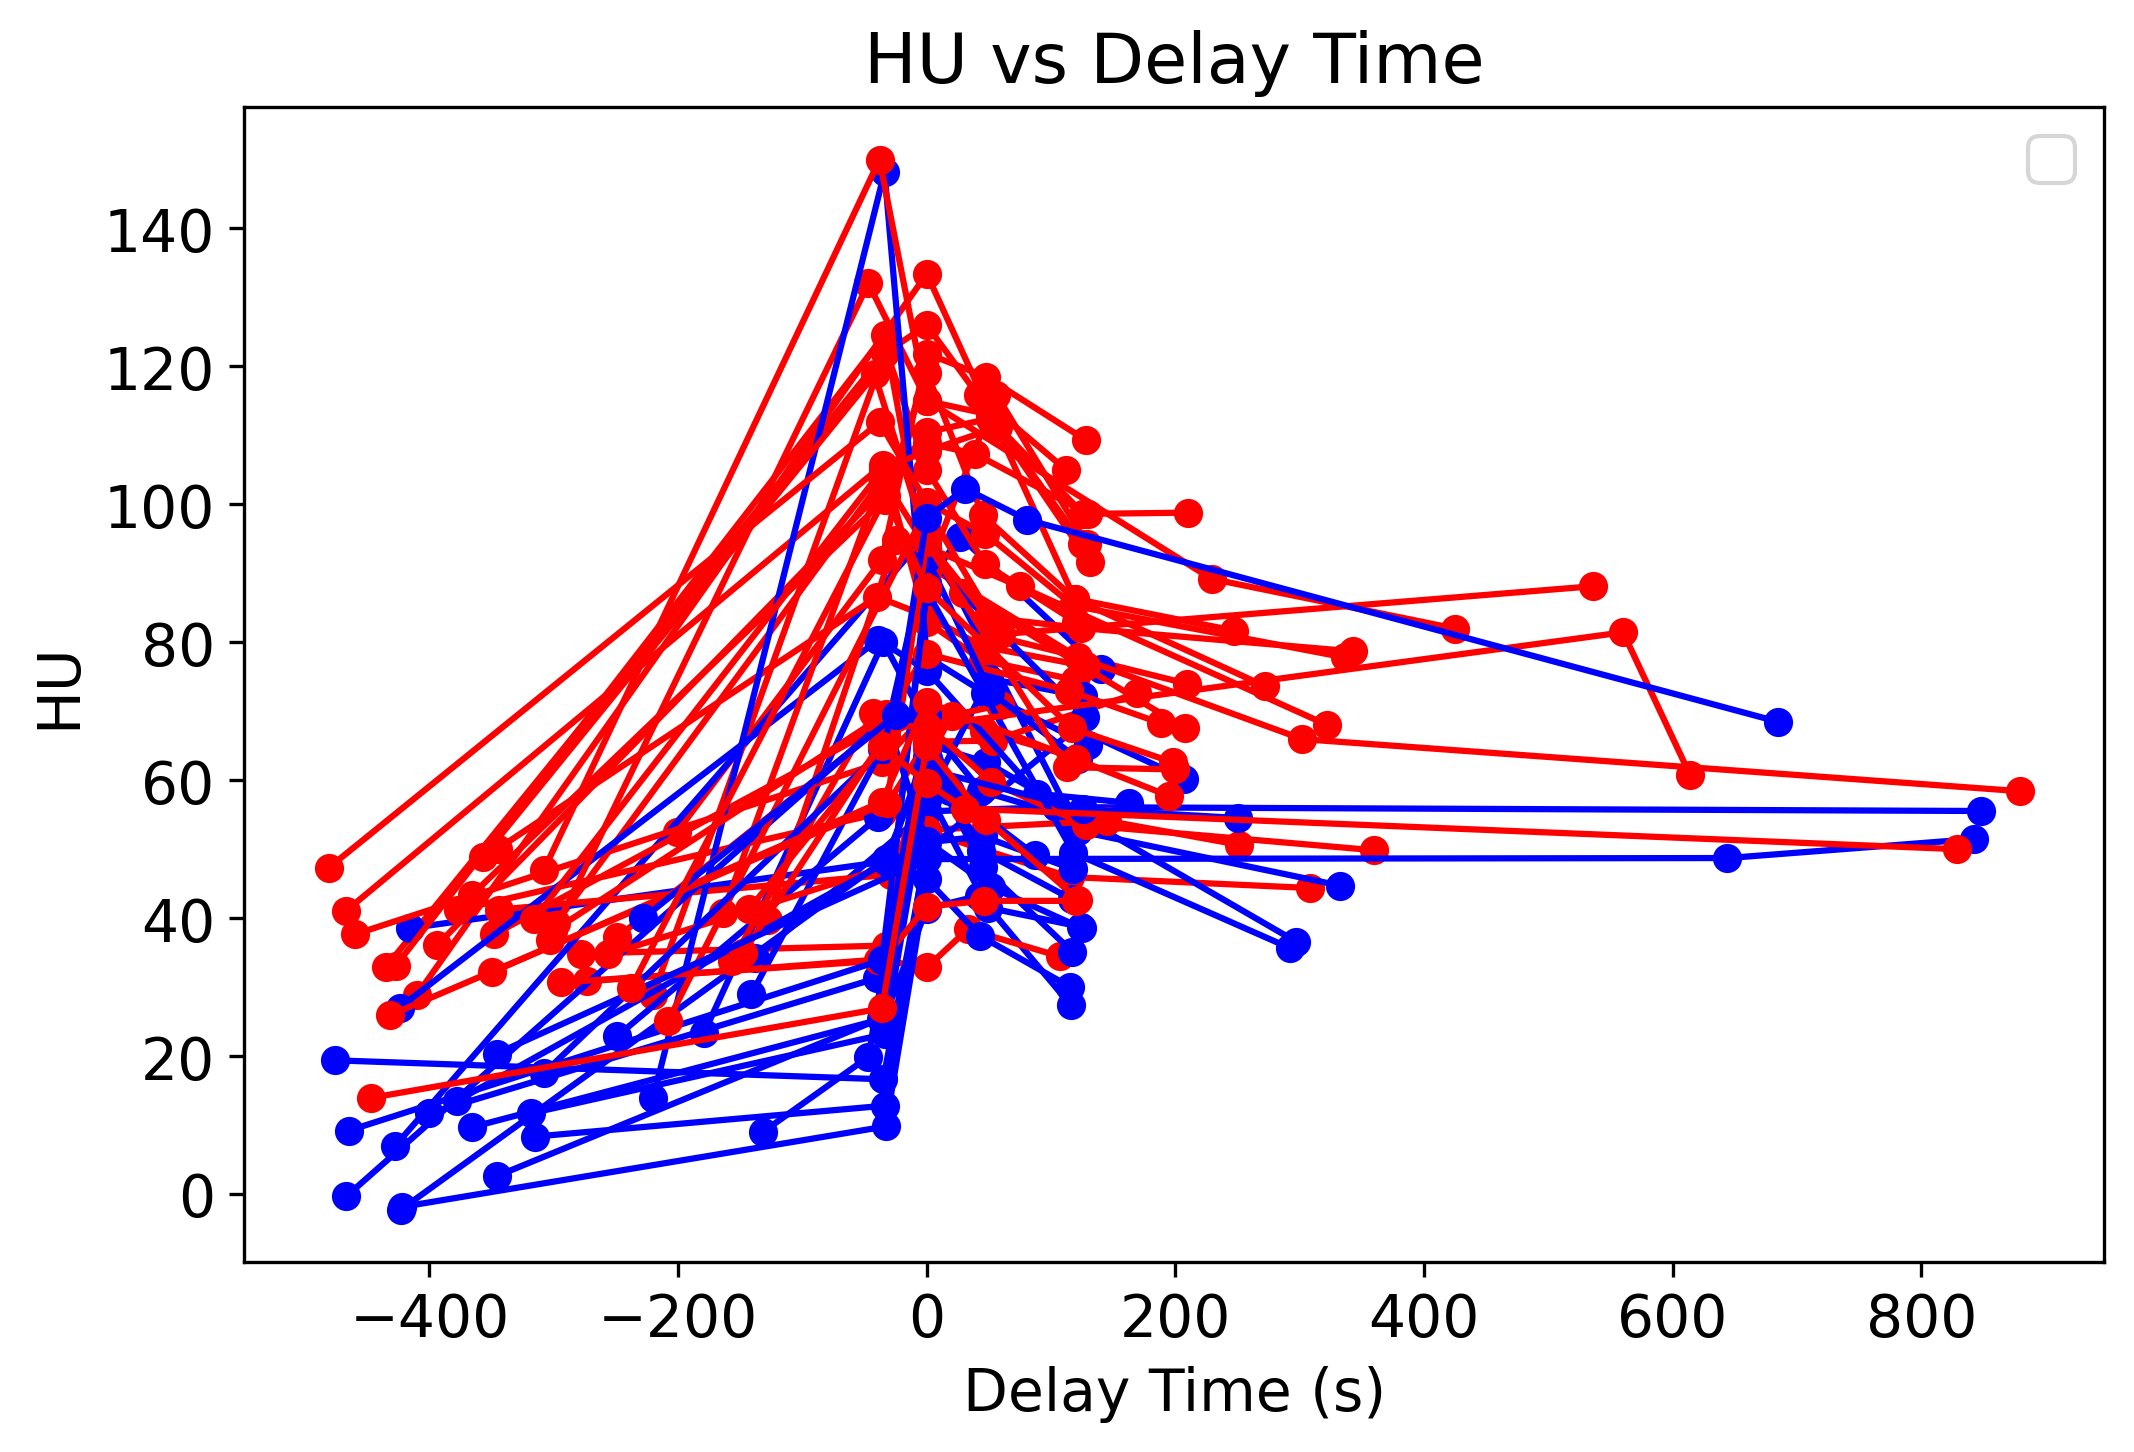

In [32]:
# iterate through the grouped instance features, and find the instances with multiple delay phases, and load the features with 
# "HU" in the feature name
instances_with_multiple_delay_phases_df = pd.read_csv(instances_multiple_delay_csv)

plt.figure(figsize=(8, 5), dpi=300)
# iterate instances_with_multiple_delay_phases_df by rows
samples = []
sample_labels = []
for index, row in instances_with_multiple_delay_phases_df.iterrows():
    mrn = row["MRN"]
    study_date = row["StudyDate"]
    malignancy = row["Malignancy"]
    # get the npy files for this instance
    npy_files = glob(os.path.join(HU_data_dir, f"{mrn}_{study_date}_*.npy"))
    # filter the npy files to exclude those with "mask" in the file name
    npy_files = [f for f in npy_files if "mask" not in f]
    print(f"Instance: MRN={mrn}, StudyDate={study_date}, Delay Count={row['Delay_count']}, Available Phases={row['Available_phases']}, Malignancy={row['Malignancy']}")
    Delay_time_list = []
    HU_list = []
    sample = []
    for npy_file in npy_files:
        mrn, study_date, phase, delay_time, lesion_side, HU = read_HU_info(npy_file)
        print(f"  Phase: {phase}, Delay Time: {delay_time}s, Lesion Side: {lesion_side}, HU: {HU}")
        Delay_time_list.append(delay_time)
        HU_list.append(HU)
        sample.append((delay_time, HU))
    # sort HU_list based on Delay_time_list
    sorted_indices = np.argsort(Delay_time_list)
    sorted_Delay_time_list = np.array(Delay_time_list)[sorted_indices]
    sorted_HU_list = np.array(HU_list)[sorted_indices]
    sorted_sample = [sample[i] for i in sorted_indices]
    samples.append(sorted_sample)
    sample_labels.append(malignancy)
    plt.plot(sorted_Delay_time_list, sorted_HU_list, marker='o', c="red" if malignancy == 1 else "blue")

plt.xlabel("Delay Time (s)")
plt.ylabel("HU")
plt.title("HU vs Delay Time")
plt.legend()
plt.show()

In [38]:
print(len(samples), len(sample_labels))

129 129


/var/folders/0j/jhw_p03509n_339vhrhc5y1w2663j_/T/ipykernel_80228/1440384845.py:128: RuntimeWarning: Mean of empty slice
  mu_neg = np.nanmean(neg, axis=0)
/Users/jjiang10/conda_envs/adrenal/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


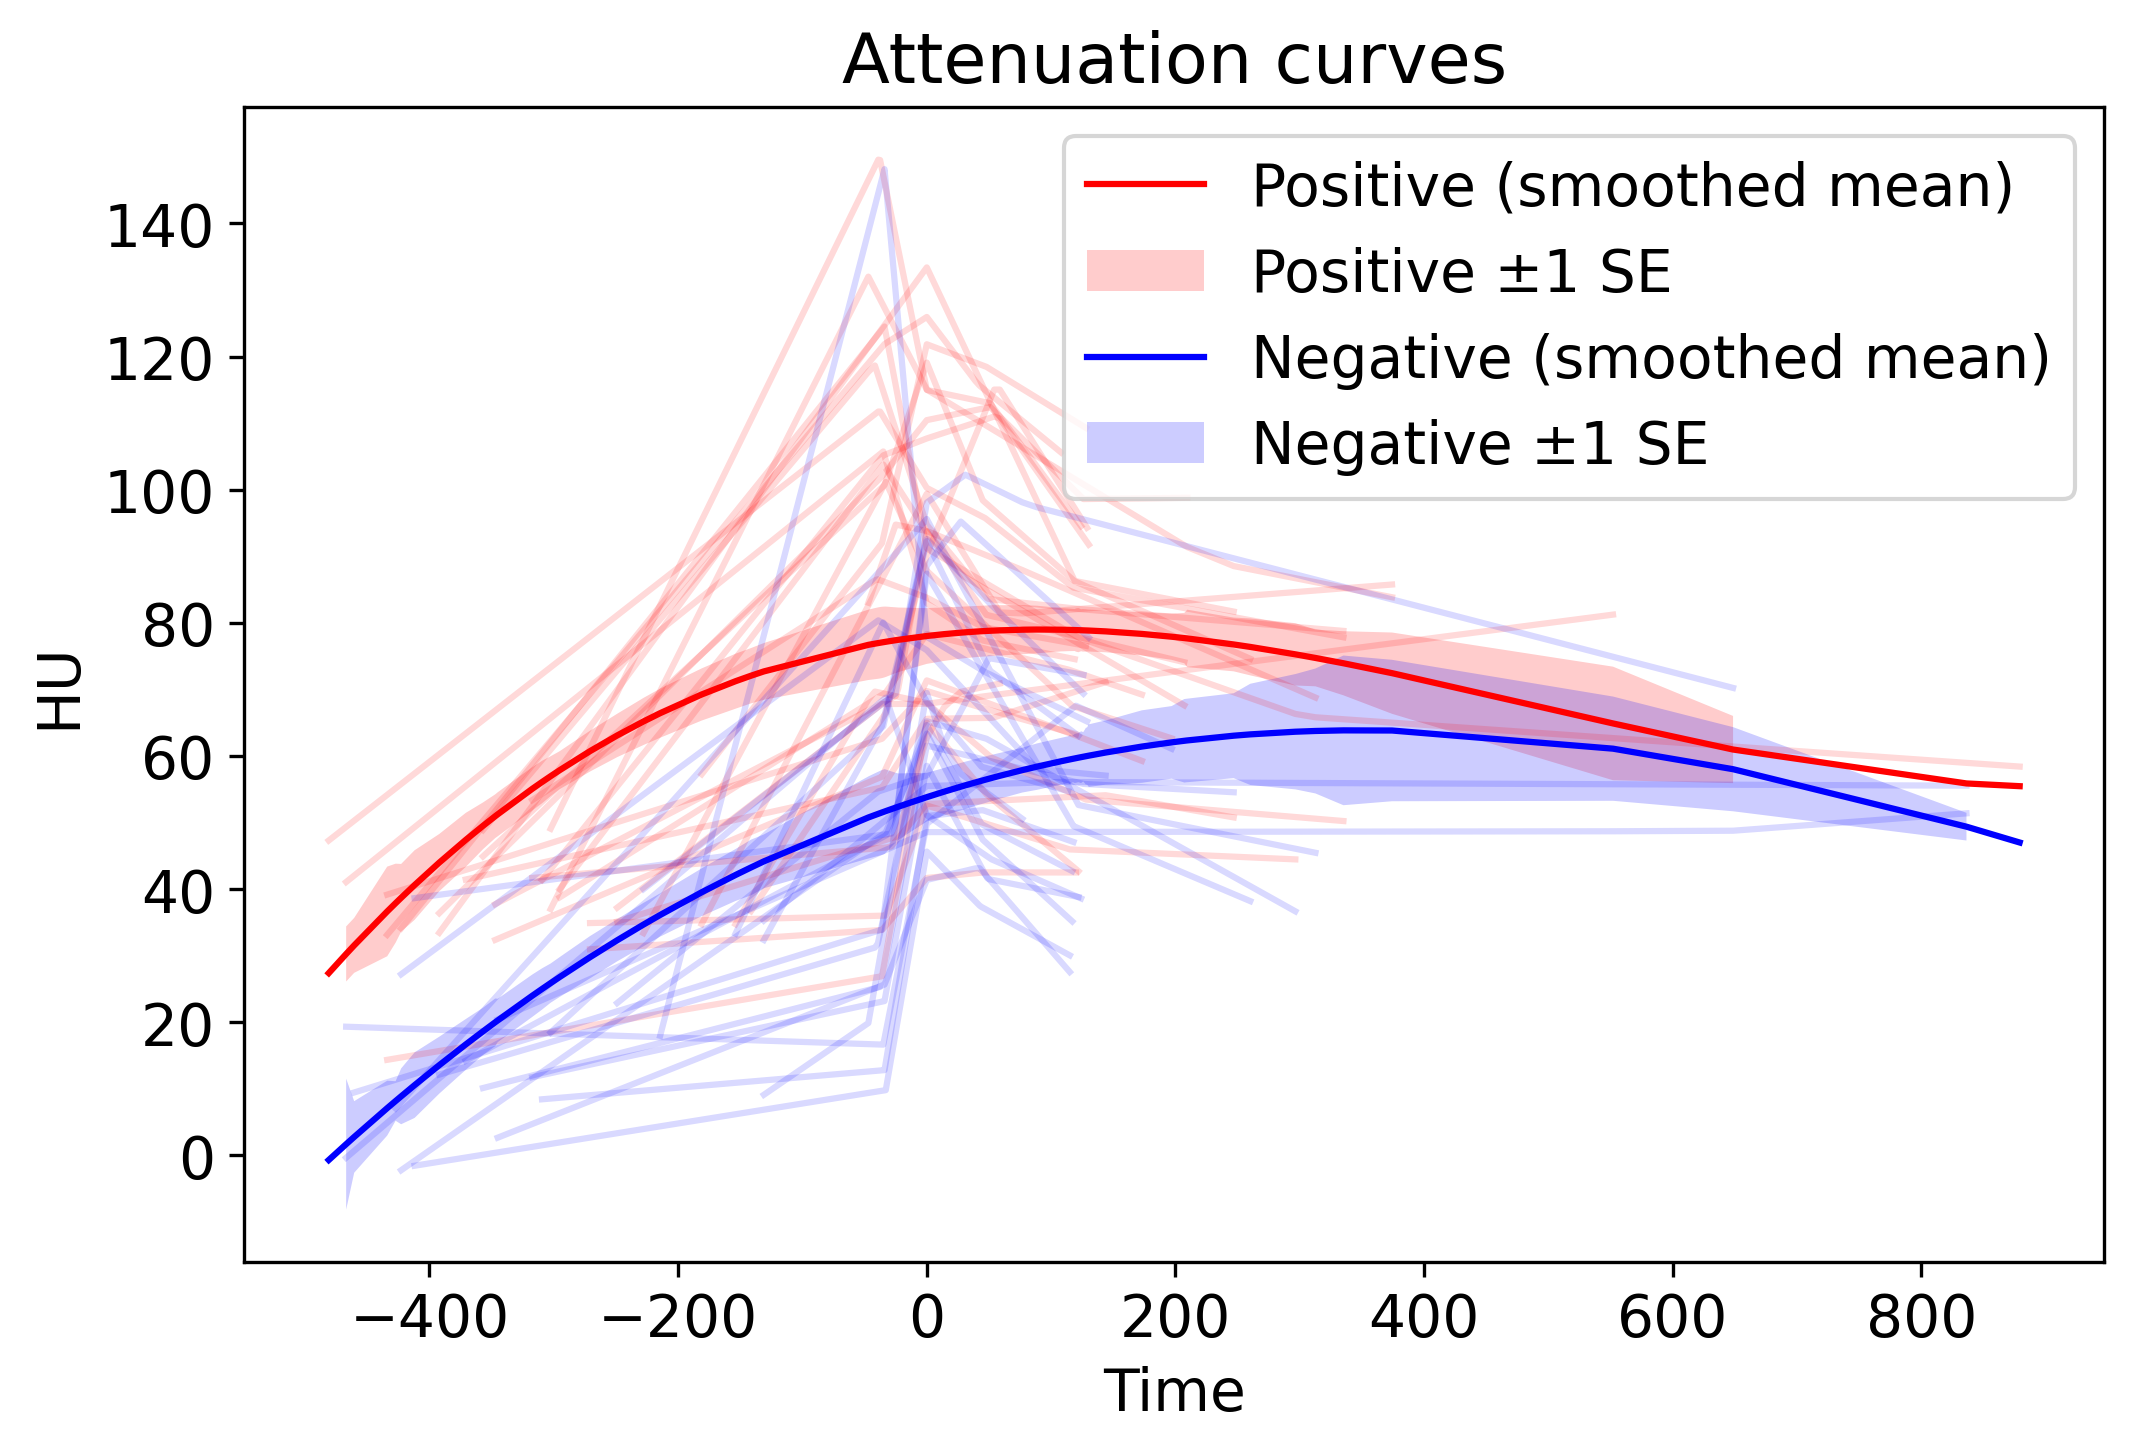

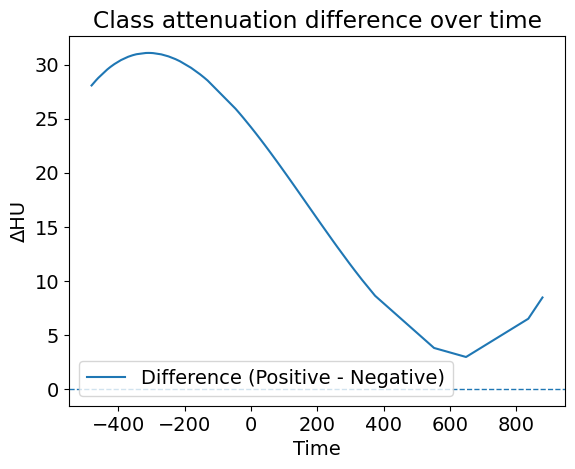

In [33]:
# -----------------------
# Cases with multiple delay phases: plot class-wise attenuation curves
res = plot_class_attenuation_curves(samples, sample_labels, show_individual=True)
# -----------------------


Instance: MRN=278483, StudyDate=20090313, Malignancy=1
  Phase: Delay, Delay Time: 161s, Lesion Side: LT.npy, HU: 58.08536585365854
  Phase: PV, Delay Time: 0s, Lesion Side: LT.npy, HU: 108.21951219512195
  Phase: AR, Delay Time: -29s, Lesion Side: LT.npy, HU: 110.01219512195122
  Phase: NC, Delay Time: -385s, Lesion Side: LT.npy, HU: 18.914634146341463
Instance: MRN=409991, StudyDate=20040727, Malignancy=1
  Phase: Delay, Delay Time: 108s, Lesion Side: RT.npy, HU: 44.78217821782178
  Phase: PV, Delay Time: 0s, Lesion Side: RT.npy, HU: 43.17079207920792
  Phase: NC, Delay Time: -217s, Lesion Side: RT.npy, HU: 26.086633663366335
  Phase: AR, Delay Time: -42s, Lesion Side: RT.npy, HU: 31.85891089108911
Instance: MRN=630789, StudyDate=20060828, Malignancy=1
  Phase: PV, Delay Time: 0s, Lesion Side: LT.npy, HU: 41.687066503467975
  Phase: AR, Delay Time: -36s, Lesion Side: LT.npy, HU: 33.87780497756018
  Phase: NC, Delay Time: -294s, Lesion Side: LT.npy, HU: 30.68482252141983
  Phase: Dela

/var/folders/0j/jhw_p03509n_339vhrhc5y1w2663j_/T/ipykernel_80228/3011748460.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


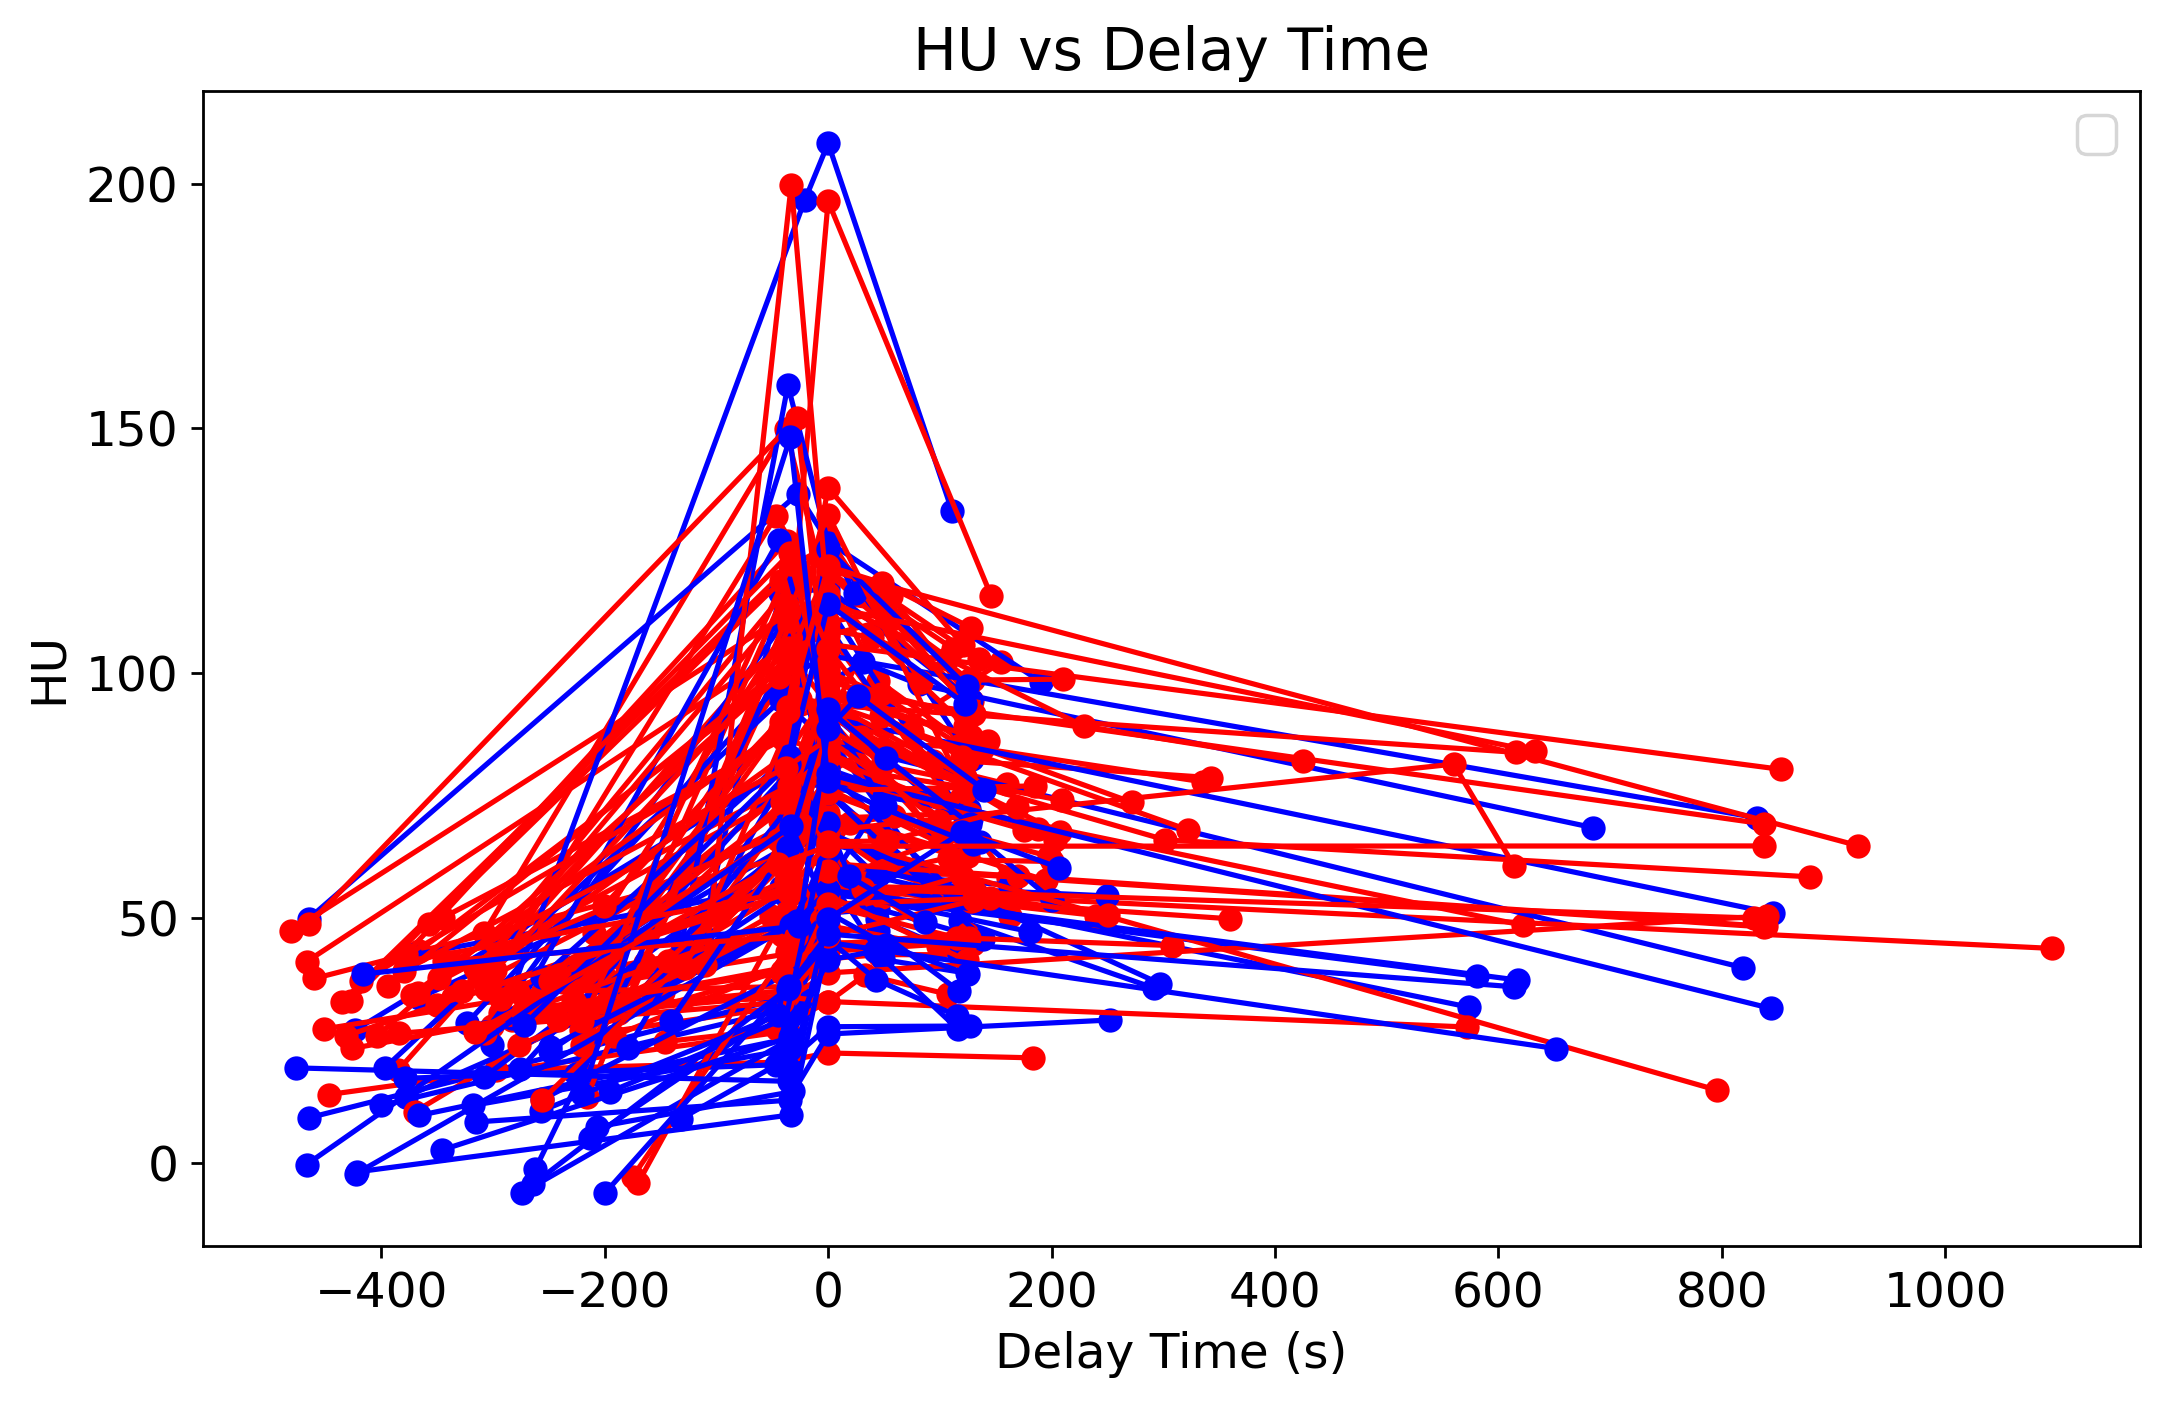

In [34]:
# use all the samples from Group 5
csv_fn = os.path.join(processed_data_root_dir, "grouped_study_by_phase_adjusted","NC_AR_PV_Delay_info.csv")
instances_within_group_5_df = pd.read_csv(csv_fn, dtype={"MRN": str, "StudyDate": str})
    
plt.figure(figsize=(10, 6), dpi=250)
# iterate instances_within_group_5_df by rows
samples = []
sample_labels = []
for index, row in instances_within_group_5_df.iterrows():
    mrn = row["MRN"]
    study_date = row["StudyDate"]
    adrenal_instance = AdrenalInstance(MRN=mrn, StudyDate=study_date, HU_data_dir=HU_data_dir, Image_data_dir=Image_data_dir)
    malignancy = adrenal_instance.get_mallignancy_label(clinical_data_file)
    # get the npy files for this instance
    npy_files = glob(os.path.join(HU_data_dir, f"{mrn}_{study_date}_*.npy"))
    # filter the npy files to exclude those with "mask" in the file name
    npy_files = [f for f in npy_files if "mask" not in f]
    print(f"Instance: MRN={mrn}, StudyDate={study_date}, Malignancy={malignancy}")
    Delay_time_list = []
    HU_list = []
    sample = []
    for npy_file in npy_files:
        mrn, study_date, phase, delay_time, lesion_side, HU = read_HU_info(npy_file)
        print(f"  Phase: {phase}, Delay Time: {delay_time}s, Lesion Side: {lesion_side}, HU: {HU}")
        Delay_time_list.append(delay_time)
        HU_list.append(HU)
        sample.append((delay_time, HU))
    # sort HU_list based on Delay_time_list
    sorted_indices = np.argsort(Delay_time_list)
    sorted_Delay_time_list = np.array(Delay_time_list)[sorted_indices]
    sorted_HU_list = np.array(HU_list)[sorted_indices]
    sorted_sample = [sample[i] for i in sorted_indices]
    samples.append(sorted_sample)
    sample_labels.append(malignancy)
    plt.plot(sorted_Delay_time_list, sorted_HU_list, marker='o', c="red" if malignancy == 1 else "blue")

plt.xlabel("Delay Time (s)")
plt.ylabel("HU")
plt.title("HU vs Delay Time")
plt.legend()
plt.show()

/var/folders/0j/jhw_p03509n_339vhrhc5y1w2663j_/T/ipykernel_80228/1440384845.py:128: RuntimeWarning: Mean of empty slice
  mu_neg = np.nanmean(neg, axis=0)
/Users/jjiang10/conda_envs/adrenal/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


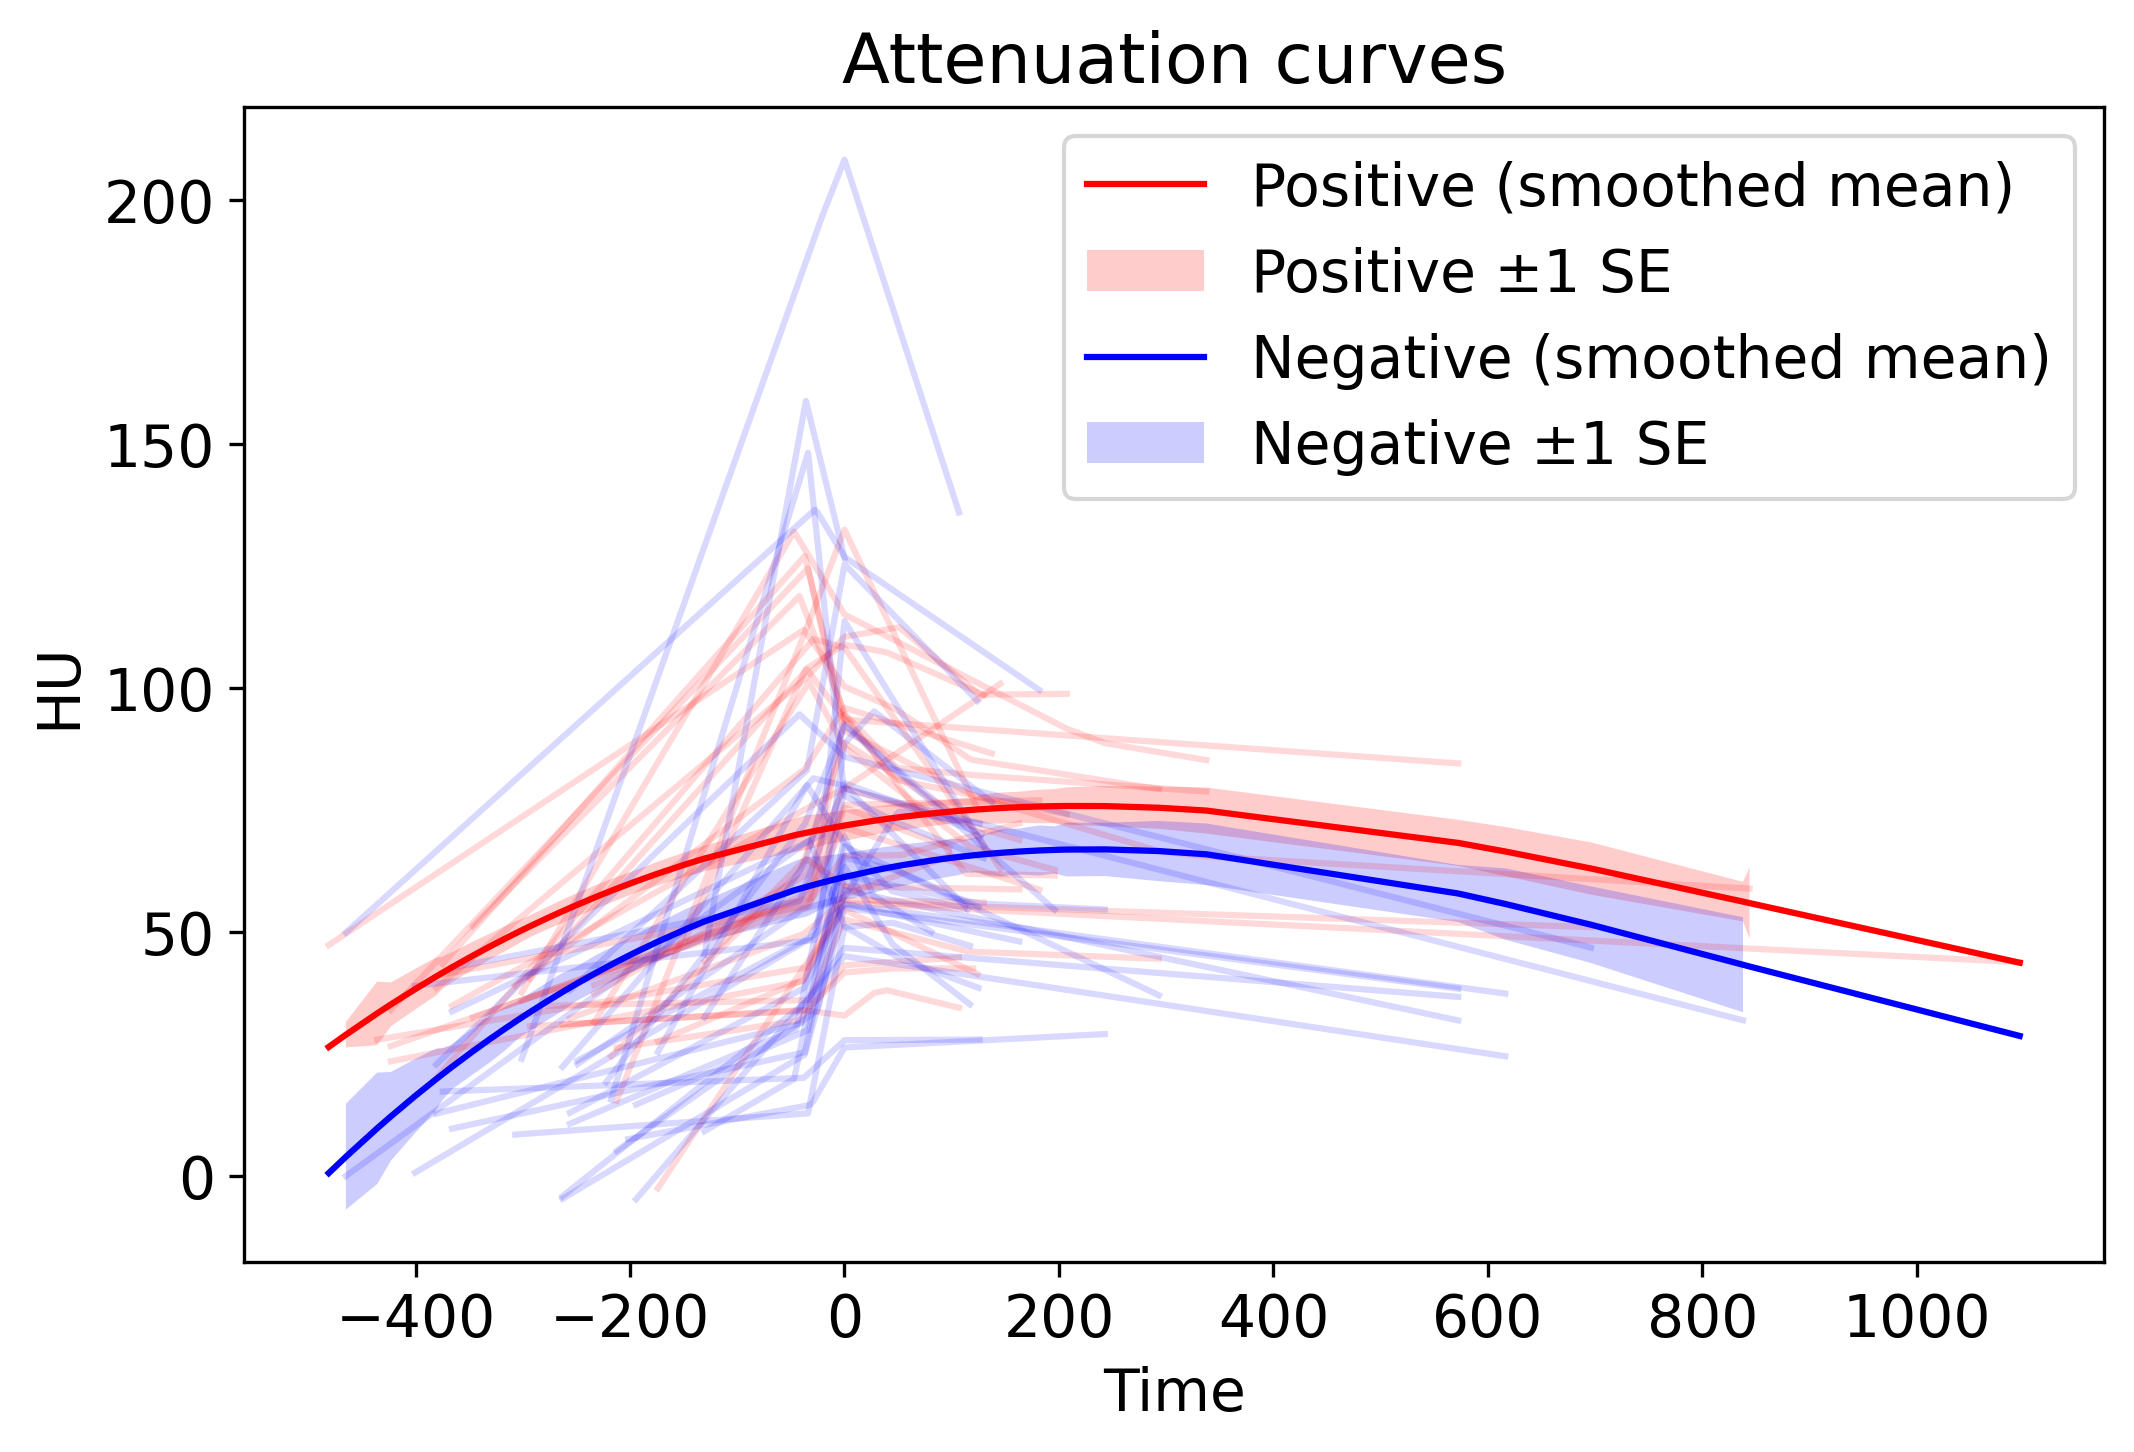

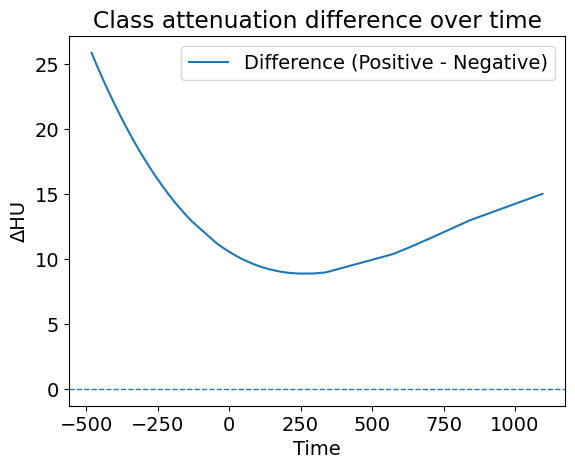

In [35]:
# -----------------------
# Group 5 attenuation curves
res = plot_class_attenuation_curves(samples, sample_labels, show_individual=True)
# -----------------------


Instance: MRN=777746, StudyDate=20090212, Malignancy=0
  Phase: NC, Delay Time: -172s, Lesion Side: LT.npy, HU: -7.788927335640138
  Phase: PV, Delay Time: 0s, Lesion Side: LT.npy, HU: 57.72087658592849
  Phase: Delay, Delay Time: 858s, Lesion Side: LT.npy, HU: 7.572664359861592
Instance: MRN=758417, StudyDate=20080902, Malignancy=0
  Phase: NC, Delay Time: -120s, Lesion Side: LT.npy, HU: 32.618915159944365
  Phase: PV, Delay Time: 0s, Lesion Side: LT.npy, HU: 156.547983310153
  Phase: Delay, Delay Time: 815s, Lesion Side: LT.npy, HU: 57.33936022253129
Instance: MRN=757982, StudyDate=20080730, Malignancy=0
  Phase: Delay, Delay Time: 1139s, Lesion Side: RT.npy, HU: 53.176663927691045
  Phase: PV, Delay Time: 0s, Lesion Side: RT.npy, HU: 71.93714050944946
  Phase: NC, Delay Time: -146s, Lesion Side: RT.npy, HU: 15.52013147082991
Instance: MRN=762508, StudyDate=20081008, Malignancy=1
  Phase: Delay, Delay Time: 844s, Lesion Side: LT.npy, HU: 45.30327868852459
  Phase: NC, Delay Time: -21

/var/folders/0j/jhw_p03509n_339vhrhc5y1w2663j_/T/ipykernel_80228/3191654544.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


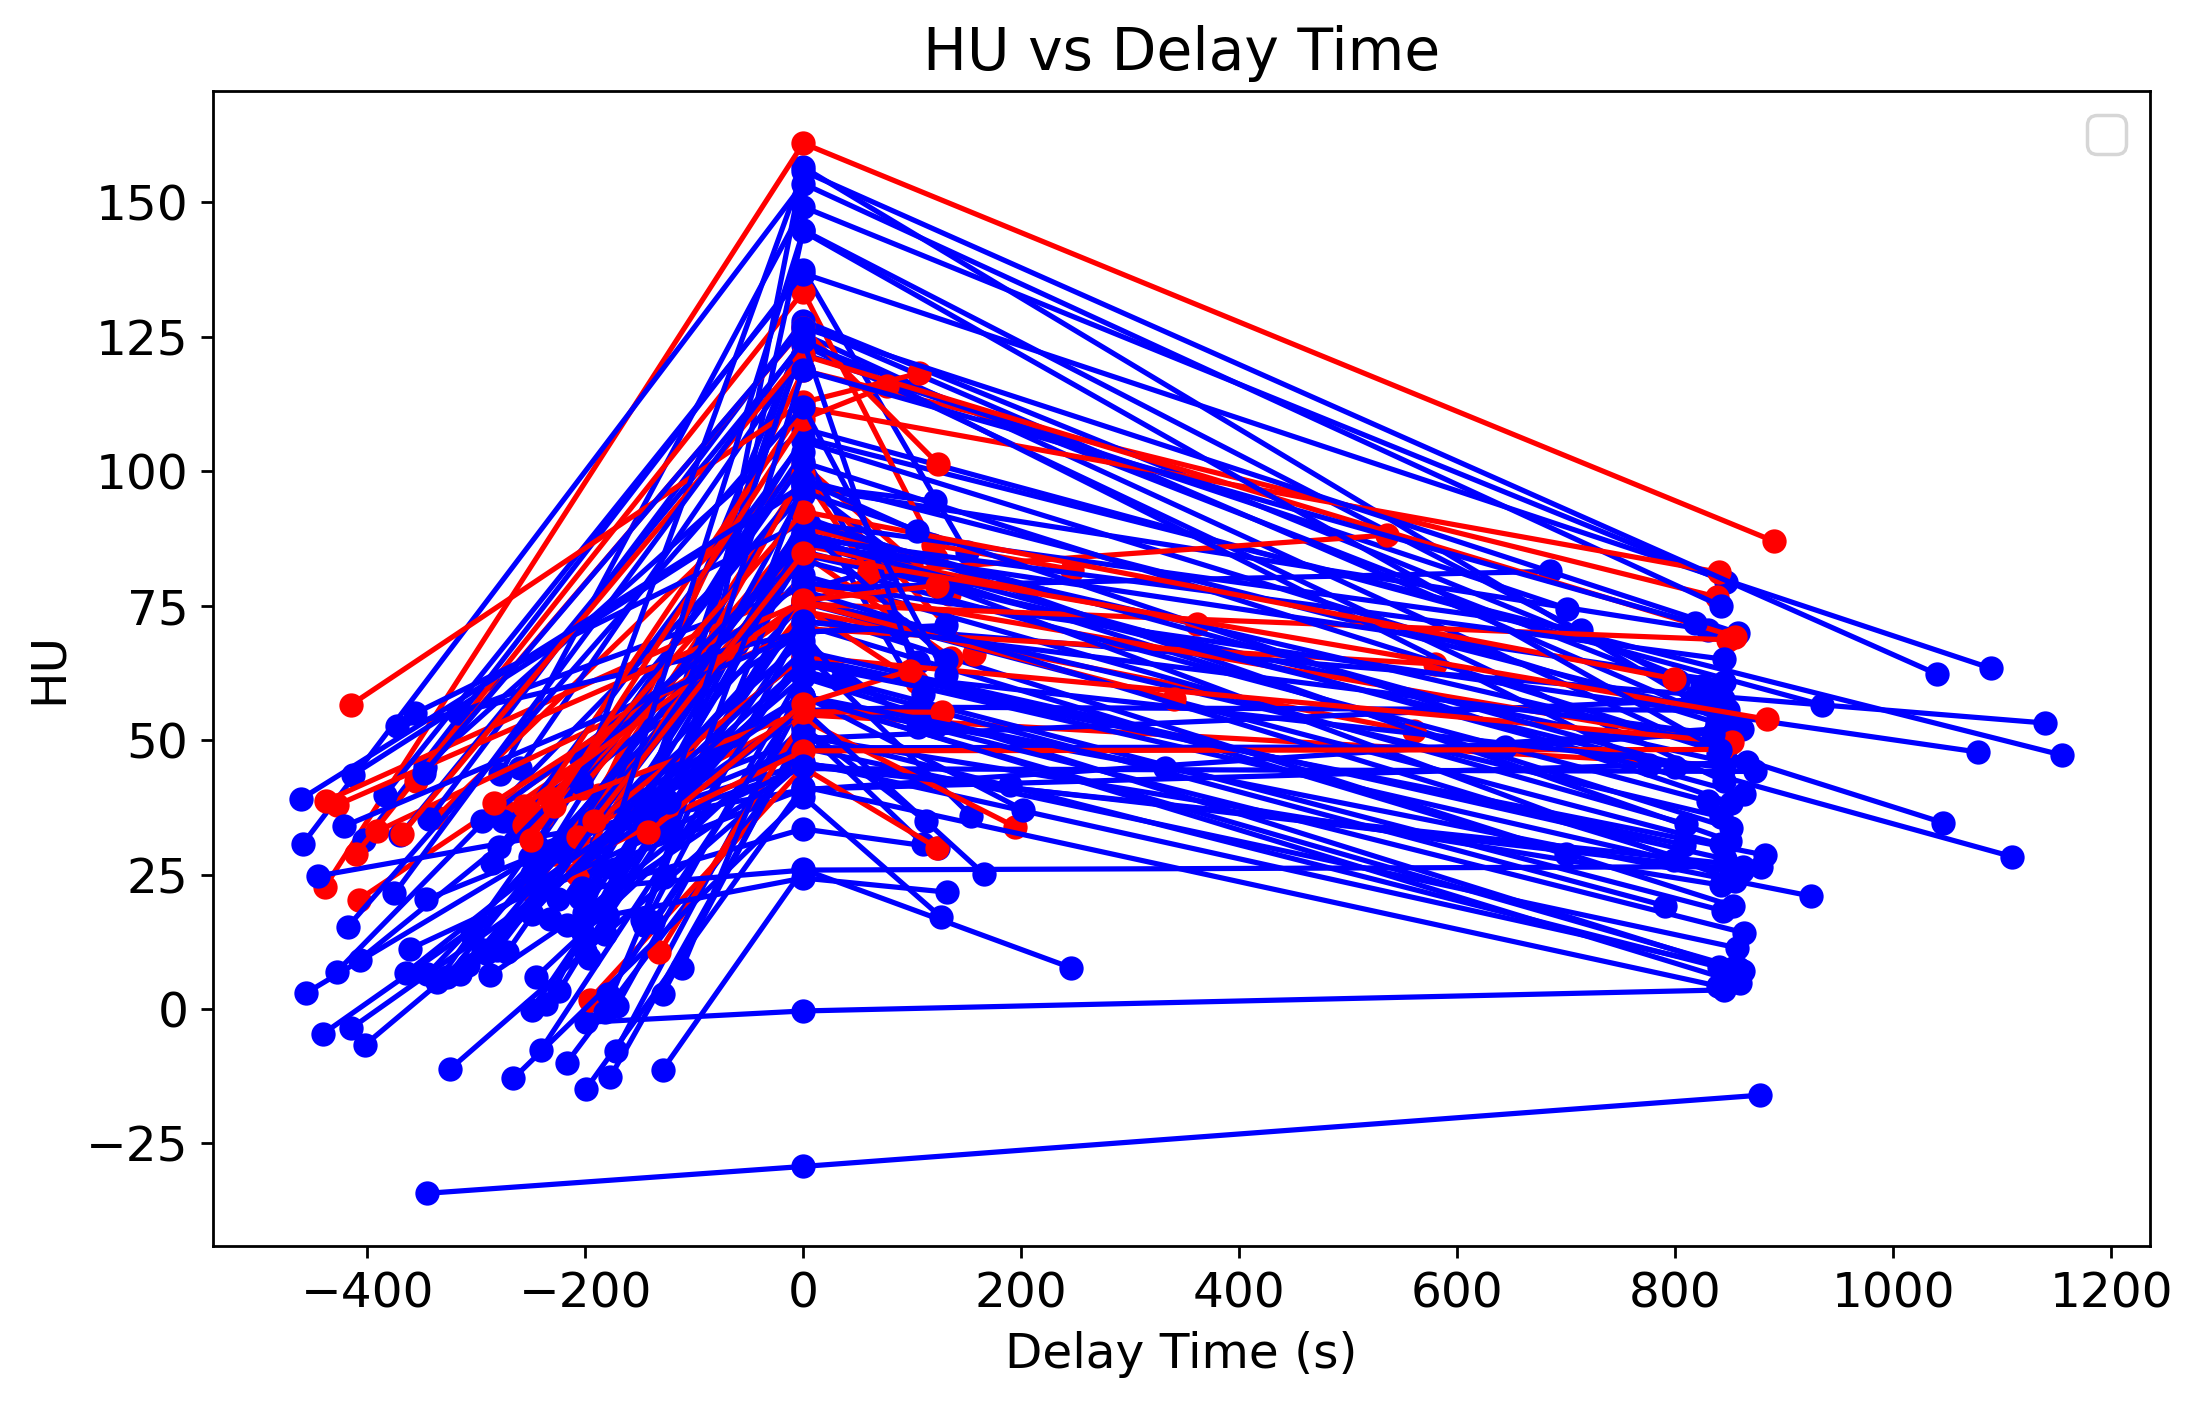

In [36]:
# use all the samples from Group 7
csv_fn = os.path.join(processed_data_root_dir, "grouped_study_by_phase_adjusted","NC_PV_Delay_info.csv")
instances_within_group_7_df = pd.read_csv(csv_fn, dtype={"MRN": str, "StudyDate": str})
    
plt.figure(figsize=(10, 6), dpi=250)
# iterate instances_within_group_7_df by rows
samples = []
sample_labels = []
for index, row in instances_within_group_7_df.iterrows():
    mrn = row["MRN"]
    study_date = row["StudyDate"]
    adrenal_instance = AdrenalInstance(MRN=mrn, StudyDate=study_date, HU_data_dir=HU_data_dir, Image_data_dir=Image_data_dir)
    malignancy = adrenal_instance.get_mallignancy_label(clinical_data_file)
    # get the npy files for this instance
    npy_files = glob(os.path.join(HU_data_dir, f"{mrn}_{study_date}_*.npy"))
    # filter the npy files to exclude those with "mask" in the file name
    npy_files = [f for f in npy_files if "mask" not in f]
    print(f"Instance: MRN={mrn}, StudyDate={study_date}, Malignancy={malignancy}")
    Delay_time_list = []
    HU_list = []
    sample = []
    for npy_file in npy_files:
        mrn, study_date, phase, delay_time, lesion_side, HU = read_HU_info(npy_file)
        print(f"  Phase: {phase}, Delay Time: {delay_time}s, Lesion Side: {lesion_side}, HU: {HU}")
        Delay_time_list.append(delay_time)
        HU_list.append(HU)
        sample.append((delay_time, HU))
    # sort HU_list based on Delay_time_list
    sorted_indices = np.argsort(Delay_time_list)
    sorted_Delay_time_list = np.array(Delay_time_list)[sorted_indices]
    sorted_HU_list = np.array(HU_list)[sorted_indices]
    sorted_sample = [sample[i] for i in sorted_indices]
    samples.append(sorted_sample)
    sample_labels.append(malignancy)
    plt.plot(sorted_Delay_time_list, sorted_HU_list, marker='o', c="red" if malignancy == 1 else "blue")

plt.xlabel("Delay Time (s)")
plt.ylabel("HU")
plt.title("HU vs Delay Time")
plt.legend()
plt.show()

/var/folders/0j/jhw_p03509n_339vhrhc5y1w2663j_/T/ipykernel_80228/1440384845.py:127: RuntimeWarning: Mean of empty slice
  mu_pos = np.nanmean(pos, axis=0)
/Users/jjiang10/conda_envs/adrenal/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


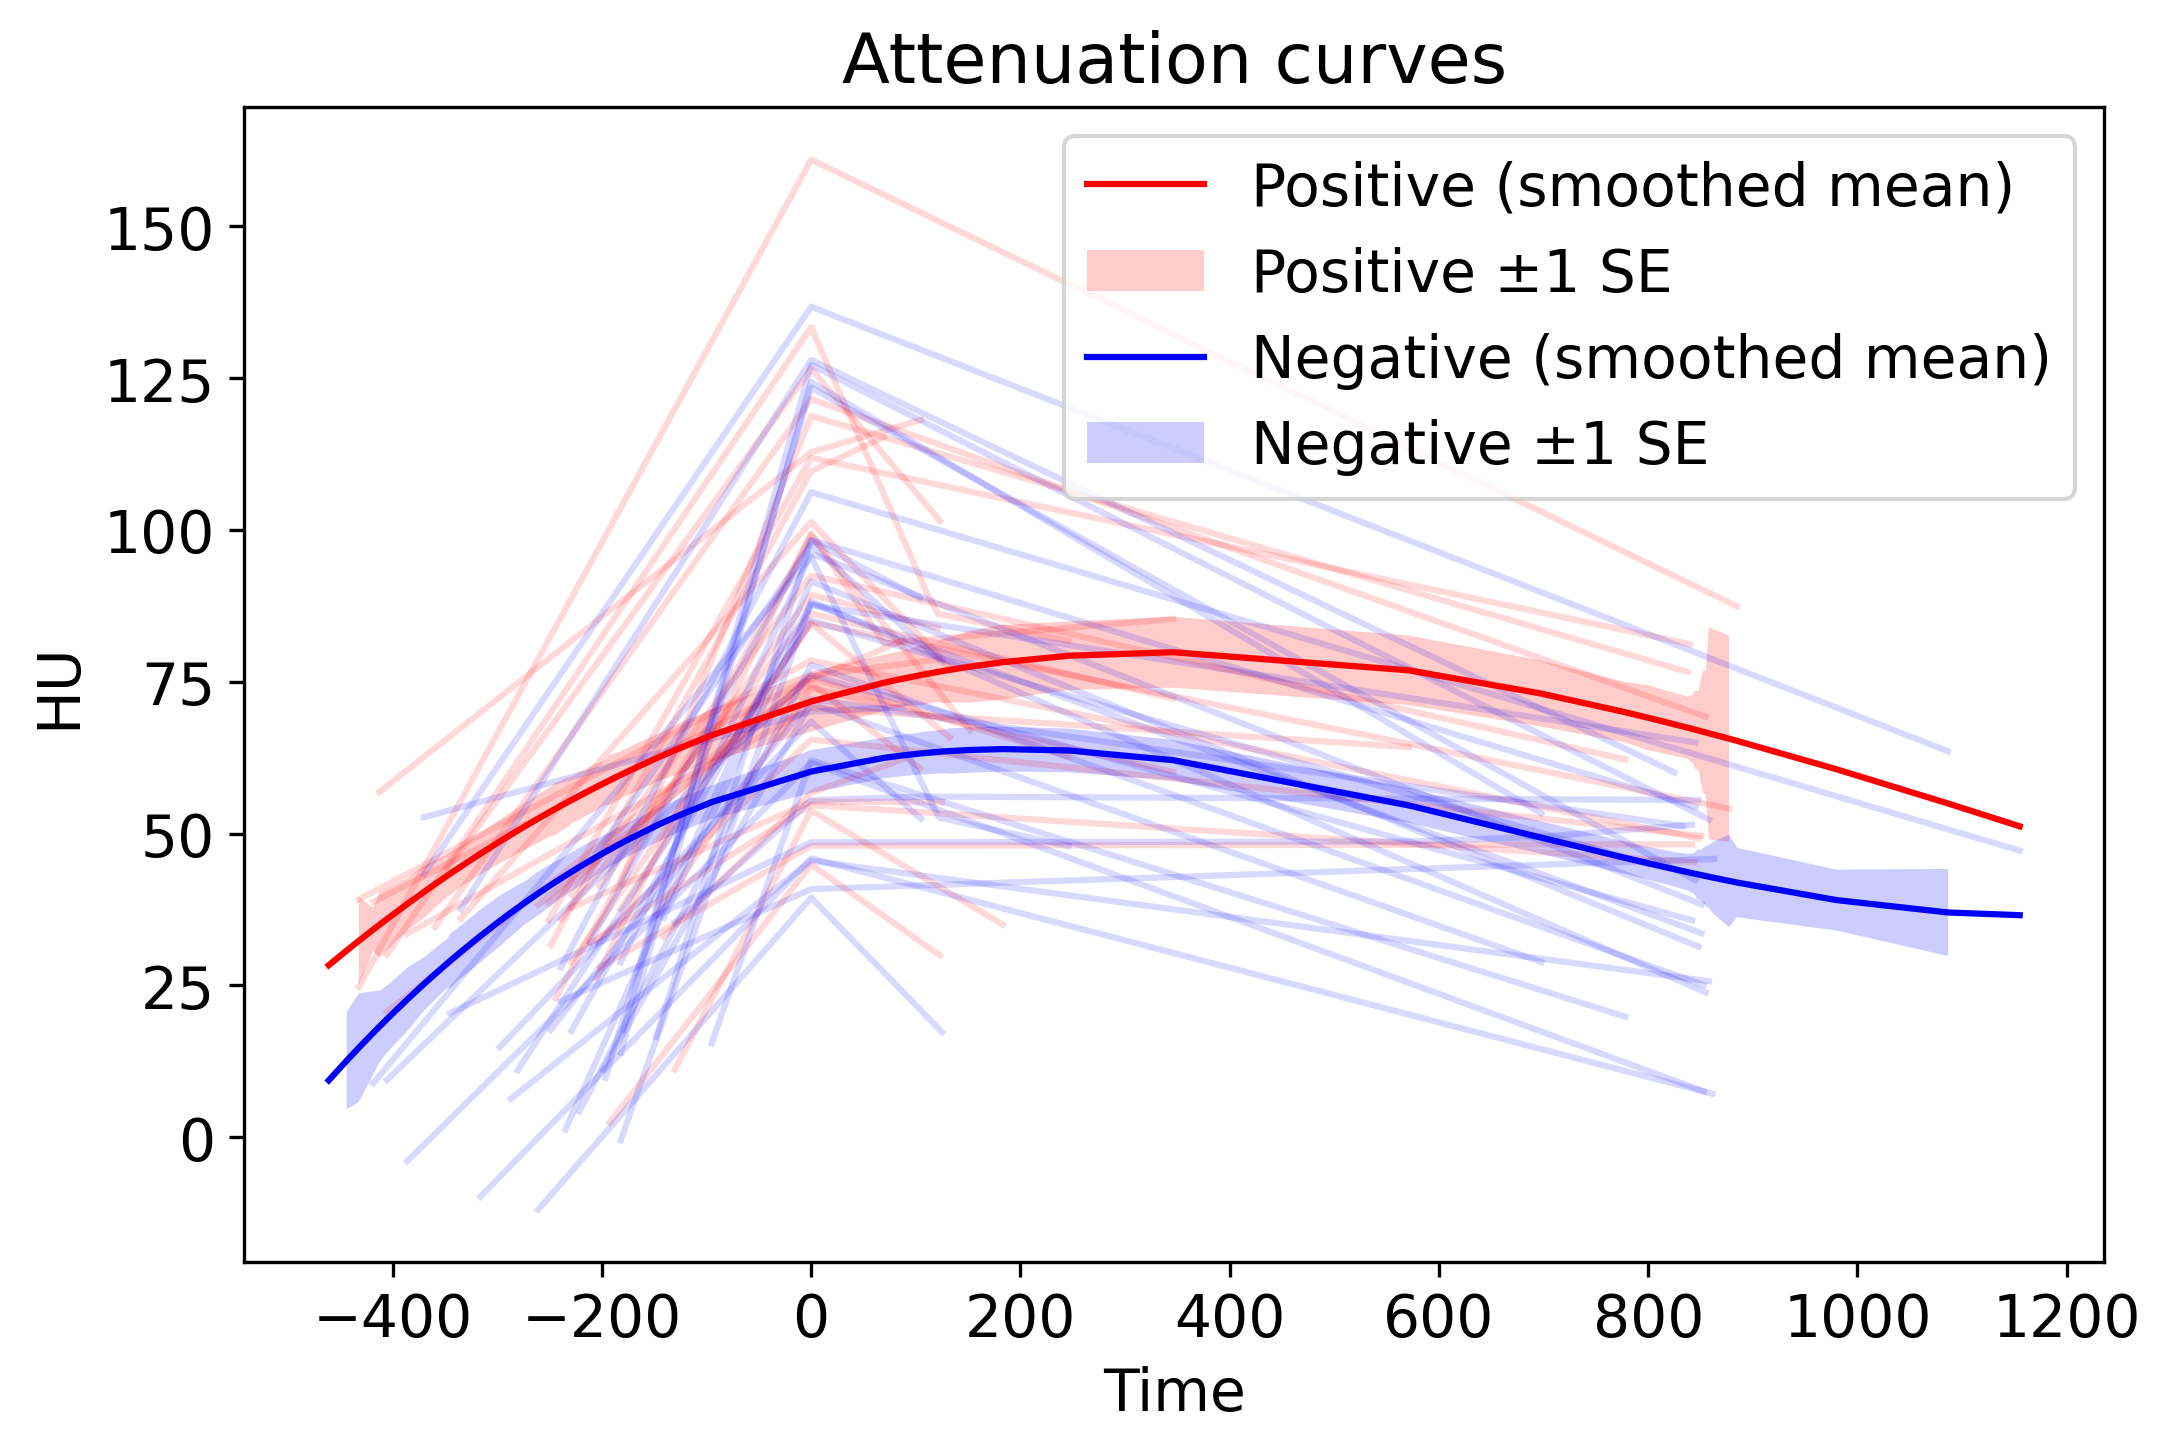

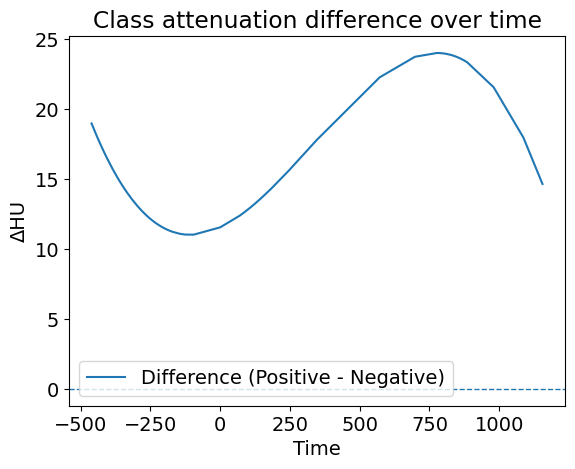

In [37]:
# -----------------------
# Group 7 attenuation curves
res = plot_class_attenuation_curves(samples, sample_labels, show_individual=True)
# -----------------------
